# A fixed-boundary CHEASE equilibrium from 0D descriptors

> What does it take to turn $R_0, a, \kappa, \delta, B_T, I_p$ into a force-balanced equilibrium, and what does the result then *not* get to choose?

A fixed-boundary Grad–Shafranov solution is fixed by three things:
1. the **boundary**;
2. the two **source functions** $p'(\psi)$ and $FF'(\psi)$;
3. one **normalization**.

`vaft.code.chease_synthesis` asks for exactly those and nothing more:

- **Boundary:** a Miller LCFS from $R_0, a, \kappa, \delta, Z_0$.
- **Sources:** generalized-parabolic *shapes* of $p'(\psi_N)$ and $FF'(\psi_N)$, plus `pressure_fraction`, the share of the on-axis source $\mu_0R_0^2p' + FF'$ that the pressure carries.
- **Normalization:** whichever one CHEASE can impose. That is the plasma current (`NCSCAL = 2`) *or* $q$ at $\psi_N = 0.95$ (`NCSCAL = 1`).

Everything else is an *achieved output*, measured on the solved equilibrium and reported beside the request: $q_0$, the other of $I_p$ and $q_{95}$, $\beta_t$, $\beta_N$, $l_i$ and the Shafranov shift.

**Requirements.** Section 1 needs only VAFT. The CHEASE sections need a CHEASE executable (`CHEASE`, `CHEASEHOME` or `CHEASE_EXEC_DIR`), and are skipped with a message when there is none.

In [ ]:
import dataclasses
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from vaft.code.chease import CHEASEConfig, find_chease_executable
from vaft.code.chease_synthesis import (
    ZeroDimensionalEquilibriumSpec, construct_boundary, synthesize_equilibrium_from_0d,
)
from vaft.data.eqdsk import read_geqdsk
from vaft.process.equilibrium import as_equilibrium, contour_shape_parameters
from vaft.formula.equilibrium import generalized_parabolic_profile
from vaft.plot.analytic import plot_solovev_equilibrium

HAVE_CHEASE = find_chease_executable() is not None
WORK = Path(tempfile.mkdtemp(prefix="vaft-0d-chease-"))
print("CHEASE available:", HAVE_CHEASE)

vest = ZeroDimensionalEquilibriumSpec(
    major_radius=0.40, minor_radius=0.235, elongation=1.7, triangularity=0.35,
    toroidal_field=0.10, plasma_current=100e3,
    pressure_fraction=0.5, pressure_alpha=1.0, pressure_beta=2.0, current_alpha=1.0, current_beta=1.0,
)

CHEASE available: True


## 1. The request: boundary and source shapes

The boundary is built first, and its shape is measured back before anything
is solved. The source shapes are shown in $\psi_N$; their common amplitude is
not an input, because CHEASE sets it to meet the normalization.

requested kappa=1.7, delta=0.35;  constructed kappa=1.7000, delta_upper=0.3500, delta_lower=0.3500


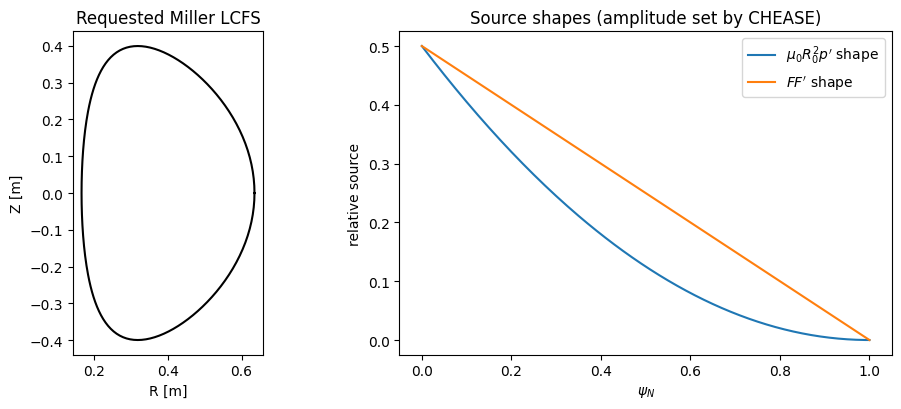

In [ ]:
boundary = construct_boundary(vest)
shape = contour_shape_parameters(boundary.r, boundary.z)
print(f"requested kappa={vest.elongation}, delta={vest.triangularity};  constructed kappa={shape['elongation']:.4f}, "
      f"delta_upper={shape['triangularity_upper']:.4f}, delta_lower={shape['triangularity_lower']:.4f}")
psi_n = np.linspace(0, 1, 201)
fig, (b_ax, s_ax) = plt.subplots(1, 2, figsize=(10, 4.2))
b_ax.plot(np.r_[boundary.r, boundary.r[0]], np.r_[boundary.z, boundary.z[0]], "k-")
b_ax.set_aspect("equal"); b_ax.set(xlabel="R [m]", ylabel="Z [m]", title="Requested Miller LCFS")
s_ax.plot(psi_n, vest.pressure_fraction*generalized_parabolic_profile(psi_n, alpha=vest.pressure_alpha, beta=vest.pressure_beta),
          label=r"$\mu_0R_0^2 p'$ shape")
s_ax.plot(psi_n, (1 - vest.pressure_fraction)*generalized_parabolic_profile(psi_n, alpha=vest.current_alpha, beta=vest.current_beta),
          label=r"$FF'$ shape")
s_ax.set(xlabel=r"$\psi_N$", ylabel="relative source", title="Source shapes (amplitude set by CHEASE)")
s_ax.legend(); fig.tight_layout(); plt.show()

## 2. Normalize to the plasma current

CHEASE solves with the requested $I_p$ (`NCSCAL = 2`). The table lists every
request next to what was achieved. $q_0$ and $q_{95}$ are outputs here, not
inputs.

With these sources, 100 kA at 0.1 T gives $q_0 \approx 0.4$ and $q_{95} \approx 2.3$.
Both are consequences of the assumptions, not targets. To aim for a given edge
safety factor, normalize to $q_{95}$ as in Section 3.

In [ ]:
def show(result):
    print(f"status: {result.status}" + (f" ({result.reason})" if result.reason else ""))
    for name, value in result.achieved.items():
        print(f"  {name:22s} {value: .5g}")
    print("  residuals:", {k: round(v, 4) for k, v in result.residuals.items()})

if HAVE_CHEASE:
    by_current = synthesize_equilibrium_from_0d(vest, config=CHEASEConfig(workdir=WORK / "ip"))
    show(by_current)
else:
    print("CHEASE not found: skipping the solves.")

status: success
  ip                      1e+05
  q0                      0.41914
  q95                     2.289
  bt0                     0.099999
  major_radius            0.4
  minor_radius            0.235
  elongation              1.6998
  geometric_center_z      0
  beta_t                  0.13152
  beta_n                  3.0906
  li_virial               1.2001
  shafranov_shift         0.044575
  magnetic_axis_r         0.44458
  magnetic_axis_z        -7.3913e-11
  volume                  0.69211
  beta_p                  0.34487
  triangularity_upper     0.3493
  triangularity_lower     0.3493
  residuals: {'plasma_current': 0.0, 'toroidal_field': -0.0, 'elongation': -0.0001, 'minor_radius': -0.0, 'major_radius': 0.0, 'triangularity_upper': -0.0007, 'triangularity_lower': -0.0007, 'vertical_position': 0.0}


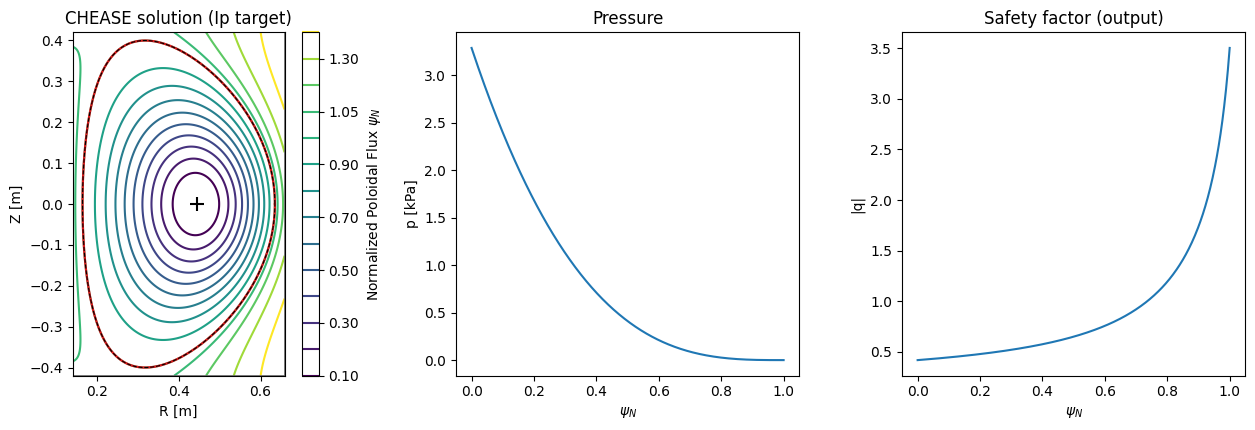

In [ ]:
if HAVE_CHEASE:
    solved = as_equilibrium(read_geqdsk(Path(by_current.chease.workdir) / "EQDSK_COCOS_02.OUT"))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    plot_solovev_equilibrium(solved, ax=axes[0], title="CHEASE solution (Ip target)")
    axes[0].plot(np.r_[boundary.r, boundary.r[0]], np.r_[boundary.z, boundary.z[0]], "k--", lw=0.8)
    x = (solved.psi_1d - solved.psi_axis) / (solved.psi_boundary - solved.psi_axis)
    axes[1].plot(x, solved.pressure / 1e3); axes[1].set(xlabel=r"$\psi_N$", ylabel="p [kPa]", title="Pressure")
    axes[2].plot(x, np.abs(solved.q)); axes[2].set(xlabel=r"$\psi_N$", ylabel="|q|", title="Safety factor (output)")
    fig.tight_layout(); plt.show()

## 3. Normalize to $q_{95}$ instead

With `NCSCAL = 1`, CHEASE matches $q(\psi_N = 0.95)$ and the plasma current
becomes the output. It is one scaling or the other; CHEASE cannot impose both
in the same solve.

The two normalizations rescale **one** solution: $p'$ and $FF'$ are multiplied
together, so the flux-surface geometry, $l_i$ and the Shafranov shift are
identical to Section 2. Only the amplitude changes: $I_p$ scales with it, and
$\beta_t$ with its square. Changing the shape of the equilibrium needs a
different source *shape*, as Section 4 shows.

In [ ]:
if HAVE_CHEASE:
    by_q = synthesize_equilibrium_from_0d(vest, target="q95", q95=6.0, config=CHEASEConfig(workdir=WORK / "q95"))
    show(by_q)

status: success
  ip                      38097
  q0                      0.79856
  q95                     6.0003
  bt0                     0.099999
  major_radius            0.4
  minor_radius            0.235
  elongation              1.6998
  geometric_center_z      0
  beta_t                  0.019088
  beta_n                  1.1774
  li_virial               1.2001
  shafranov_shift         0.044575
  magnetic_axis_r         0.44458
  magnetic_axis_z        -7.3913e-11
  volume                  0.69211
  beta_p                  0.34487
  triangularity_upper     0.3493
  triangularity_lower     0.3493
  residuals: {'q95': 0.0, 'toroidal_field': -0.0, 'elongation': -0.0001, 'minor_radius': -0.0, 'major_radius': 0.0, 'triangularity_upper': -0.0007, 'triangularity_lower': -0.0007, 'vertical_position': 0.0}


## 4. The same 0D description, different equilibria

Geometry, $B_T$ and $I_p$ do not determine an equilibrium. Changing only the
source assumptions -- the pressure share, or how peaked the current source is
-- gives a different $q_0$, $\beta_t$, $l_i$ and Shafranov shift, all with
the same boundary and current. That is why the source model is an explicit,
required input here, and not a hidden default.

(The default sources give $\beta_t \approx 13\,\%$ at 0.1 T. That is a
consequence of the assumed pressure share, not a realistic VEST baseline.)

In [ ]:
if HAVE_CHEASE:
    variants = {
        "baseline": vest,
        "pressure share 0.2": dataclasses.replace(vest, pressure_fraction=0.2),
        "pressure share 0.8": dataclasses.replace(vest, pressure_fraction=0.8),
        "peaked current": dataclasses.replace(vest, current_beta=3.0),
    }
    print(f"{'variant':20s} {'q0':>6s} {'q95':>6s} {'beta_t':>7s} {'li':>6s} {'shift [cm]':>10s} {'Ip [kA]':>8s}")
    for name, spec in variants.items():
        r = synthesize_equilibrium_from_0d(spec, config=CHEASEConfig(workdir=WORK / name.replace(" ", "_")))
        a = r.achieved
        print(f"{name:20s} {a['q0']:6.2f} {a['q95']:6.2f} {a['beta_t']:7.3f} {a['li_virial']:6.2f} "
              f"{100*a['shafranov_shift']:10.2f} {a['ip']/1e3:8.1f}  [{r.status}]")

variant                  q0    q95  beta_t     li shift [cm]  Ip [kA]


baseline               0.42   2.29   0.132   1.20       4.46    100.0  [success]


pressure share 0.2     0.62   2.31   0.040   1.01       2.94    100.0  [success]


pressure share 0.8     0.23   2.23   0.298   1.54       6.17    100.0  [success]


peaked current         0.19   2.04   0.332   2.08       6.28    100.0  [success]


## 5. What is refused, and how

A quantity CHEASE cannot impose is refused as `unsupported_target`, not
silently treated as an output or reached by editing the result. Invalid
geometry and invalid source models are also refused before CHEASE runs.

In [ ]:
for label, result in (
    ("beta_p target", synthesize_equilibrium_from_0d(vest, target="beta_p")),
    ("minor radius > R0", synthesize_equilibrium_from_0d(dataclasses.replace(vest, minor_radius=0.5))),
    ("pure-pressure source", synthesize_equilibrium_from_0d(dataclasses.replace(vest, pressure_fraction=1.0))),
):
    print(f"{label:22s} -> {result.status}: {result.reason}")

beta_p target          -> unsupported_target: CHEASE can normalize to ['plasma_current', 'q95'] only; 'beta_p' would be an output, not a control
minor radius > R0      -> invalid_geometry: requires major_radius > minor_radius > 0
pure-pressure source   -> invalid_source_model: pressure_fraction must lie in [0, 1): FF' may not vanish identically
